# Case 2b -- Temporal Velocity Change: Morning Shading Response (Phaseolus, M10)

**Dissertation Chapter 6, Section 6.2.2, "Temporal Velocity Changes as a Reaction to Leaf Shading" (p. 116):**

> In contrast to the previous examples involving spatially resolved tracer dynamics, this study
> investigates the temporal response of tracer velocity within a single plant subjected to an
> environmental perturbation.
>
> [...] Two measurements were performed on the same phaseolus plant: one in the morning at 11:00
> ("Morning") and one in the afternoon at 16:00 ("Afternoon").
>
> To model changing velocities, a custom time-dependent velocity profile was used in
> CADET-Process. [...] This resulted in a profile with three change points per measurement,
> corresponding to transitions between an initial stable phase, a decline phase during shading,
> and a recovery phase.

- Data: `Phas_6_M10_Internode_below_leaf.txt`.
- Model: single MCT (2-channel) unit with a custom time-dependent velocity profile (3 constant
  phases + 2 transition ramps, plus a fitted smoothing width `p_s`), fitted alongside
  flow/exchange/porosity/dispersion structural parameters (13 parameters total).
- Reproduces: Figure `fig:global_M10` (`Figures/M10_global.pdf`, `Figures/M10_global_v.pdf`).
- Companion notebooks: `phas_v_change_M10_control.ipynb` (3h-prior control, M09),
  `phas_v_change_M10_control_daybefore.ipynb` (previous-day control, M06), and the Afternoon
  (M12) counterpart `case2b_temporal_velocity_shading_phaseolus_afternoon.ipynb`.

## Imports

In [1]:
from CADETProcess.processModel import Inlet, MCT, Outlet, TubularReactor
from CADETProcess.processModel import ComponentSystem, MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet, Process
from CADETProcess.simulator import Cadet
from CADETProcess.optimization import OptimizationProblem, NelderMead, TrustConstr
from scipy.ndimage import convolve1d

from IPython import display

from utils import compute_jacobian, compute_parameter_uncertainties, interpolate_cb_from_simulation_results, plot_live_fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.makedirs("output/figures", exist_ok=True)


## Load and preprocess experimental data

In [3]:
df = pd.read_csv("data/case2b_M10_internode.csv", index_col=0)
df.columns = df.columns.astype(float)  # CSV headers are strings; these are numeric distances (mm)

In [4]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

xi=list(np.array(xi)[[3,4,6,7,8,9,10,11]])

exp_data = data_cor*np.exp(-0.000567*60*t.reshape(len(t),1))

Force monotonicity in the first 3 points of each ROI (these are noise-dominated near the detection threshold) and prepend two zero-activity time points at the start.

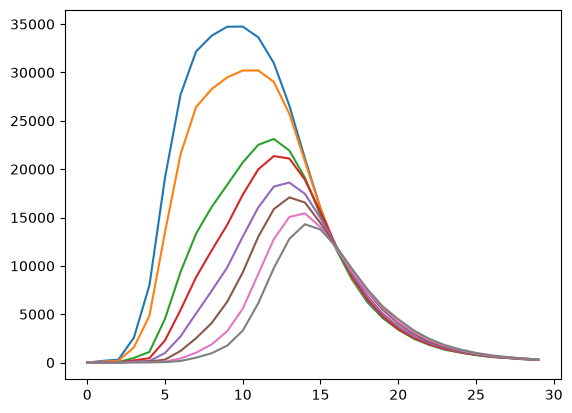

In [5]:

normalized_data = (data_cor[:,[3,4,6,7,8,9,10,11]].T  - data_cor[:,[3,4,6,7,8,9,10,11]].T .min(axis=1, keepdims=True)).T

monotonic_data = normalized_data.copy().T

# Force monotonicity in the first 3 points of each row
for i in range(monotonic_data.shape[0]):
    # Set monotonicity to match the trend from the 4th point
    baseline = monotonic_data[i, 3]*0.1
    monotonic_data[i, :3] = np.linspace(monotonic_data[i, 0], baseline, 3)

plt.plot(monotonic_data.T/np.exp(0.000567*60*t.reshape(len(t),1)))

smooth_exp_data = monotonic_data.T/np.exp(0.000567*60*t.reshape(len(t),1))

exp_data = smooth_exp_data
exp_data = exp_data / np.max(exp_data)

num_new_rows = 2
num_columns = exp_data.shape[1]

new_rows = np.zeros((num_new_rows, num_columns))

exp_data = np.vstack((new_rows, exp_data))
t = np.hstack((t,[150.,155.]))

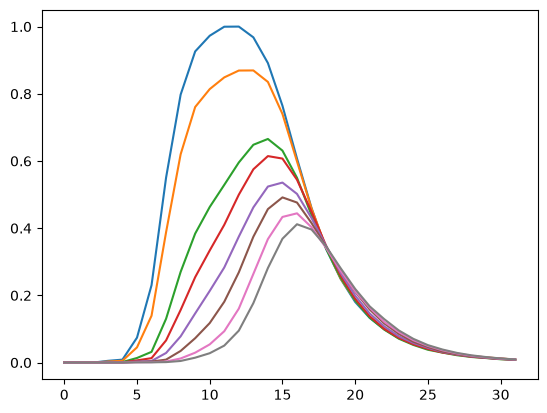

In [6]:
plt.plot(exp_data)

## Velocity profile and process model

In [7]:
def exponential_kernel(size=200, scale=20.0):
    """
    Continuous exponential kernel for smoothing.

    Parameters:
        size (int): Number of kernel points (support size).
        scale (float): Controls the exponential decay length (continuous).

    Returns:
        np.ndarray: Normalized exponential kernel.
    """
    size = int(size)
    x = np.linspace(-size / 2, size / 2, size)
    kernel = np.exp(-np.abs(x) / scale)
    return kernel / kernel.sum()

# Updated Three-Point Model with Initial Constant Velocity (Using t1, t2, t3)
def velocity_profile(t, p_v0, p_t1, p_t2, p_t3, p_v2, p_v3, smoothing_width=100):
    """
    Generates a velocity profile with an initial constant velocity before change at t1.
    
    Parameters:
        t (numpy.ndarray): Time points to evaluate the velocity profile.
        p_v0 (float): Initial constant velocity.
        p_t1 (float): Duration for which velocity remains constant at p_v0.
        p_t2 (float): Time interval for velocity change.
        p_t3 (float): Time interval for recovery.
        p_v2 (float): Velocity at t2 (after change).
        p_v3 (float): Velocity at t3 (after recovery).
        smoothing_width (int): Width of the exponential kernel for smoothing.
    
    Returns:
        numpy.ndarray: Smoothed velocity profile.
    """
    time_points = [0, p_t1, p_t2, p_t3]  # Ensure an initial constant phase
    velocities = [p_v0, p_v0, p_v2, p_v3]  # Hold velocity constant before change

    profile = np.interp(t, time_points, velocities)

    kernel = exponential_kernel(smoothing_width, scale=smoothing_width)
    smoothed_profile = convolve1d(profile, kernel, mode="nearest")

    return smoothed_profile


In [8]:
def setup_process(x):
    
    p_volumetric_flow_rate_const_t0 = x[0]
    p_mct1_e12 = x[1]
    p_total_porosity = x[2]
    p_col_dispersion = x[3]
    p_x0 = x[4]
    p_dt1= x[5]
    p_dt2= x[6]
    p_dt3= x[7]
    p_v2= x[8] 
    p_v3= x[9]
    p_t0 =x[10]
    p_s=x[11]
    p_mct_disp=x[12]

        
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    tube = TubularReactor(component_system, name='stem')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 30

    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system

    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(tube)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(outlet)
    
    tube.length = p_x0
    tube.axial_dispersion = 0
    tube.diameter = np.sqrt(1/np.pi)

    leaf.total_porosity = p_total_porosity
    leaf.length = 0.01
    leaf.diameter = np.sqrt(1/np.pi)*15
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, tube)
    mct_flow_sheet.add_connection(tube, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, outlet, origin_port = 'channel_0')
 
    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[-1]/1000
    
    mct1.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct_disp
    
    mct1.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                    ])
                                

    process.cycle_time = 60*t[-1]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [1],0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [1],p_t0*60+0.1)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0],p_t0*60+6*60)
    
    t_curve = np.linspace(0, t[-1] * 60, len(t)*5)
  
    
    p_t1 = p_dt1
    p_t2 = p_dt2
    p_t3 = p_dt3
    
  
    curve_modified =velocity_profile(t_curve, p_v0=p_volumetric_flow_rate_const_t0, p_t1=p_t1 * 60, p_t2=p_t2 * 60, p_t3=p_t3 * 60, 
                                    p_v2=p_v2, p_v3=p_v3, smoothing_width=p_s)

    process.add_flow_rate_profile(inlet, t_curve, curve_modified)
    
    #plt.plot(t_curve, curve_modified, label="Smoothed Profile")
    #_ = process.plot_events()    

        
    return process

## Parameter normalization

In [9]:
# Define min and max values for each parameter

param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 2e-04),  # log-scaling, volumetric_flow_rate_const
    'mct1_e12': (1.53039589e-5, 6.12158354e-03),  # log-scaling, mct1_e12
    'total_porosity': (0.1, 0.99),          # linear scaling, total_porosity
    'col_dispersion': (2.83319089e-12, 1.13327635e-04),  # log-scaling, col_dispersion
    'x0': (0.001, 0.05),           # linear scaling, t0
    'p_t1': (0, 25),
    'p_t2': (25, 60),
    'p_t3': (60, 120),
    'p_v2': (1e-05, 8e-05),
    'p_v3': (1e-05, 2e-04),
    'p_t0': (0, 10),
    'p_s': (1, 50),
    'mct_dispersion': (2.83319089e-10, 1.13327635e-04)}

problem = OptimizationProblem("case2b_temporal_velocity_shading_morning")
for pname, (lb, ub) in param_bounds.items():
    problem.add_variable(pname, evaluation_objects=None, lb=lb, ub=ub, normalization="auto")

## Objective function

`_forward_model` runs the simulation once; `objective` (scalar SSQ, for the optimizer) and `residuals` (weighted residual vector, for the Jacobian/uncertainty estimate below) both build on it instead of duplicating the simulation call. The original notebook also had a third, dead `objective` function (skipped denormalization, used a stale unit index inconsistent with the other two) -- removed.

In [10]:
def _forward_model(x):
    """Simulate the process; return (calc_data, time_new)."""
    process = setup_process(x)

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0] * 60, t[-1] * 60 + 5 * 60, 5 * 60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [v / 1000 for v in xi]
    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new=eval_location1)
    calc_data = np.sum(cb_mct1, axis=2).squeeze()
    calc_data = calc_data / np.max(calc_data)

    return calc_data, time_new

def objective(x):
    """NMSRE = mean((calc - exp)^2) / mean(exp^2); used as the optimizer's objective."""
    calc_data, time_new = _forward_model(x)
    residuals = calc_data - exp_data
    nmsre = np.mean(residuals ** 2) / np.mean(exp_data ** 2)
    _obj_history.append(nmsre)
    if _live_plot_active:
        plot_live_fit(time_new, calc_data, exp_data, _obj_history)
    return nmsre

def residuals(x):
    """Weighted residual vector; used for the numerical Jacobian / uncertainty estimate."""
    calc_data, time_new = _forward_model(x)
    residuals = calc_data - exp_data
    return residuals.ravel() / np.sqrt(np.mean(exp_data ** 2))

problem.add_objective(objective, n_objectives=1)

## Plotting helper

In [11]:
_obj_history = []
_live_plot_active = False

In [12]:
simulator = Cadet()    
simulator.time_resolution = 60
simulator.use_dll = True

## Optimization



In [13]:


x_best_fit_published = np.array([
    0.00010568234699999999, 0.00015504043179529958, 0.3686279257,
    2.248615553893223e-09, 0.04179416355, 17.1657105, 47.55487115, 79.075185,
    3.6324755800000005e-05, 9.13905394e-05, 3.8306982, 3.1175207900000004,
    1.2975516906031971e-08,
])

def run_optimization(optimize=False, live_plot=False, method="tc+nm", x0=None):
    """
    optimize  : False  return x_best_fit_published without running the optimizer
                True   run the optimizer and return the converged x
    method    : "nm"     NelderMead only
                "tc"     TrustConstr only
                "nm+tc"  NelderMead then TrustConstr
                "tc+nm"  TrustConstr then NelderMead
    x0        : starting point in real units; defaults to x_best_fit_published
    live_plot : show live fit and objective progress during optimization
    """
    global _live_plot_active, _obj_history
    if not optimize:
        return x_best_fit_published

    if x0 is None:
        x0 = x_best_fit_published

    _live_plot_active = live_plot
    _obj_history = []

    if method in ("nm", "nm+tc"):
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    if method in ("tc", "nm+tc", "tc+nm"):
        tc = TrustConstr()
        tc.gtol = 1e-5
        tc.xtol = 1e-5
        tc.barrier_tol = 1e-5
        result_tc = tc.optimize(problem, x0=x0, save_results=False)
        x0 = result_tc.x[0]

    if method == "tc+nm":
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    x_best_fit = x0
    for pname, value in zip(param_bounds.keys(), x_best_fit):
        print(f"{pname:<35}{value:<20.8e}")
    _live_plot_active = False
    return x_best_fit

x_best_fit = run_optimization()

## Final fit figure (`fig:global_M10` panel b, `Figures/M10_global.pdf`)

In [14]:
def plot_for_publication(x):

    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+60,60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
   

    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14) 
    
    t_plot = [ -10, -5, 0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145.]
    
    time_new_plot = np.arange(-10,145+1,1)

    plt.plot(time_new_plot[10:],calc_data[10:], label="Simulated Data", linewidth=1.5)
    plt.gca().set_prop_cycle(None)
    plt.plot(t_plot[2:],exp_data[2:], '.',  markersize=8,label="Experimental Data",)
    
    plt.xlabel("Time [min]")
    plt.ylabel("Activity [a.u.]")
    
    
    # Remove duplicate labels while keeping the first occurrence
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = {}
    unique_handles = []

    for handle, label in zip(handles, labels):
        if label not in unique_labels:  # Keep first occurrence
            unique_labels[label] = handle
            unique_handles.append(handle)

    # Add legend with unique labels
    plt.legend(unique_handles, unique_labels.keys(), fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=20)
    plt.ylabel("Activity [a.u.]", fontsize=20)
    plt.savefig("output/figures/M10_global.pdf", format="pdf")

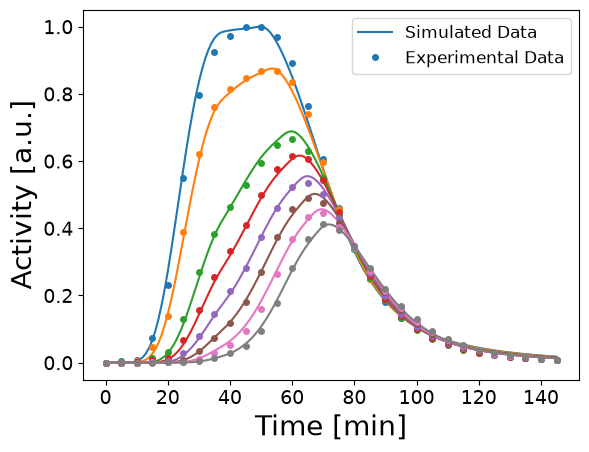

In [15]:
plot_for_publication(x_best_fit)

Historical record (pasted output, not executable) of denormalized parameters and Jacobian-based uncertainties for an earlier snapshot of x_best_fit:

```
Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    1.05186780e-04      0.50      
mct1_e12                      1.55084952e-04      0.39      
total_porosity                3.67436376e-01      0.30      
col_dispersion                2.27124333e-09      0.38      
x0                            4.18034539e-02      0.83      
p_t1                          1.71976385e+01      0.69      
p_t2                          4.75665958e+01      0.64      
p_t3                          7.90870836e+01      0.32      
p_v2                          3.63389336e-05      0.38      
p_v3                          9.14549684e-05      0.43      
p_t0                          3.83570510e+00      0.38      
p_s                           3.12244382e+00      0.04      
mct_dispersion                1.30034532e-08      0.30   
Parameter 0: ±12.667518444933885%
Parameter 1: ±1.9020030450957373%
Parameter 2: ±4.595847726985865%
Parameter 3: ±1.8388469330787722%
Parameter 4: ±44.914687529072786%
Parameter 5: ±43.11176737676474%
Parameter 6: ±2.92399562177335%
Parameter 7: ±10.782578893643011%
Parameter 8: ±5.054362702071136%
Parameter 9: ±4.538610679823591%
Parameter 10: ±8181514.765619075%
Parameter 11: ±7558.110391788354%
Parameter 12: ±25.39374467918571%
```


## Velocity profile figure (`fig:global_M10` panel a, `Figures/M10_global_v.pdf`)

Velocity/time values are read directly from `x_best_fit` rather than retyped as literals. **Note**: `uncertainties_time`/`uncertainties_velocity` below are still hardcoded fractions manually transcribed from an earlier Jacobian-based uncertainty calculation rather than computed live from `x_best_fit` -- flagged for the author to verify/replace, not changed here.

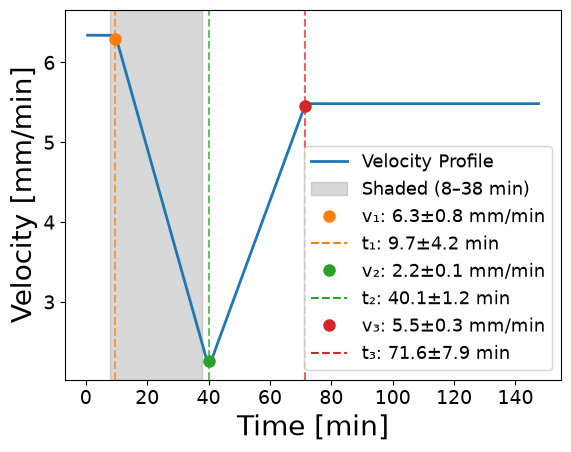

In [16]:
param_names = list(param_bounds.keys())
best_x_phys = dict(zip(param_names, x_best_fit))

p_v0 = best_x_phys['volumetric_flow_rate_const']
p_t1 = best_x_phys['p_t1']
p_t2 = best_x_phys['p_t2']
p_t3 = best_x_phys['p_t3']
p_v2 = best_x_phys['p_v2']
p_v3 = best_x_phys['p_v3']

t_plot = np.linspace(0, 155 * 60, len(t) * 60)

final_process = setup_process(x_best_fit)
smoothed_interpolated = final_process.parameter_timelines['flow_sheet.inlet.flow_rate'].value(t_plot) * (1 / 1.66667e-5)

plt.style.use('default')

key_times_min = [p_t1 - 10 + 2.5, p_t2 - 10 + 2.5, p_t3 - 10 + 2.5]
velocities = np.array([p_v0, p_v2, p_v3]) * (1 / 1.66667e-5)
uncertainties_time = [0.43, 0.03, 0.11]
uncertainties_velocity = [0.12, 0.05, 0.05]

import matplotlib.lines as mlines

t_plot = np.linspace(-10 + 2.5, 145 + 2.5, len(t) * 60)
plt.plot(t_plot[100:], smoothed_interpolated[100:], label="Velocity Profile", linewidth=2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.ylim(top=np.max(smoothed_interpolated) * 1.05)
plt.ylim(bottom=np.min(smoothed_interpolated) * 0.9)

plt.axvspan(8, 38, color='gray', alpha=0.3, label="Shaded (8\u201338 min)")

custom_handles = []

def to_subscript(number):
    subscript_digits = str.maketrans("0123456789", "\u2080\u2081\u2082\u2083\u2084\u2085\u2086\u2087\u2088\u2089")
    return str(number).translate(subscript_digits)

for idx, key_time in enumerate(key_times_min):
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][idx + 1]

    nearest_index = np.abs(t_plot - key_time).argmin()
    y_value = smoothed_interpolated[nearest_index]
    velocity = velocities[idx]
    velocity_unc = velocity * uncertainties_velocity[idx]
    time_unc = key_time * uncertainties_time[idx]

    plt.axvline(x=key_time, linestyle='--', color=color, alpha=0.7)
    plt.plot(key_time, y_value, 'o', color=color, markersize=8)

    sub = to_subscript(idx + 1)
    velocity_label = f'v{sub}: {velocity:.1f}\u00b1{velocity_unc:.1f} mm/min'
    dot_handle = mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=8, label=velocity_label)
    custom_handles.append(dot_handle)

    time_label = f't{sub}: {key_time:.1f}\u00b1{time_unc:.1f} min'
    line_handle = mlines.Line2D([], [], linestyle='--', color=color, label=time_label)
    custom_handles.append(line_handle)

plt.xlabel("Time [min]", fontsize=20)
plt.ylabel("Velocity [mm/min]", fontsize=20)

default_handles, default_labels = plt.gca().get_legend_handles_labels()
plt.legend(default_handles + custom_handles, default_labels + [h.get_label() for h in custom_handles], fontsize=13, loc='lower right')
plt.savefig("output/figures/M10_global_v.pdf", format="pdf")
plt.show()

## Parameter uncertainties

Uses the notebook's original `np.linalg.inv`.

In [17]:
param_uncertainties = compute_parameter_uncertainties(residuals, x_best_fit, use_pinv=False)
rel_param_uncertainties = param_uncertainties / np.abs(x_best_fit)

for i, uncertainty in enumerate(rel_param_uncertainties):
    print(f"Parameter {i}: \u00b1{uncertainty * 100:.2f}%")

Parameter 0: ±24.00%
Parameter 1: ±4.23%
Parameter 2: ±10.07%
Parameter 3: ±26.99%
Parameter 4: ±53.06%
Parameter 5: ±71.69%
Parameter 6: ±1.29%
Parameter 7: ±2.59%
Parameter 8: ±3.57%
Parameter 9: ±3.89%
Parameter 10: ±69.67%
Parameter 11: ±5090.14%
Parameter 12: ±145.35%
